In [16]:
"""
Spatial navigation trajectory and flow field visualization
--------------------------------------------------------
This script generates:
1. Object-by-repetition trajectory + flow field plots
2. Single-object detailed trajectory visualization

Requirements:
- pandas
- numpy
- scipy
- matplotlib
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as colors
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from scipy.stats import sem

# =========================
# CONFIG
# =========================


ARENA_RADIUS = 90
OBJECTS = ['donut','barrel','cone','football','pawn','vase']

# =========================
# CORE FUNCTIONS
# =========================

def compute_velocity(df):
    df = df.copy()
    df = df.sort_values(["Rnum","trial_num","time"])
    df["vx"] = df.groupby(["Rnum","trial_num"])["pos_x"].diff() / df.groupby(["Rnum","trial_num"])["time"].diff()
    df["vz"] = df.groupby(["Rnum","trial_num"])["pos_z"].diff() / df.groupby(["Rnum","trial_num"])["time"].diff()
    df = df.loc[
    ~((df["vx"].abs() < 0.001) & (df["vz"].abs() < 0.001))]
    return df.dropna()


def compute_flow(trial, x_edges, z_edges):

    x, z = trial.pos_x.values, trial.pos_z.values
    vx, vz = trial.vx.values, trial.vz.values

    C, _, _ = np.histogram2d(z, x, bins=[z_edges, x_edges])
    U_sum, _, _ = np.histogram2d(z, x, bins=[z_edges, x_edges], weights=vx)
    V_sum, _, _ = np.histogram2d(z, x, bins=[z_edges, x_edges], weights=vz)

    with np.errstate(divide="ignore", invalid="ignore"):
        U = U_sum / C
        V = V_sum / C

    U[np.isnan(U)] = 0
    V[np.isnan(V)] = 0

    return U, V, C


def average_trajectory_with_ci(trial, n_points=100):

    subjects = trial.Rnum.unique()
    X, Z = [], []

    for sub in subjects:
        traj = trial[trial.Rnum == sub]
        x, z = traj.pos_x.values, traj.pos_z.values

        if len(x) < 2:
            continue

        t = np.linspace(0,1,len(x))
        t_new = np.linspace(0,1,n_points)

        fx = interp1d(t, x)
        fz = interp1d(t, z)

        X.append(fx(t_new))
        Z.append(fz(t_new))

    X, Z = np.array(X), np.array(Z)

    mean_x, mean_z = X.mean(0), Z.mean(0)

    se_x, se_z = sem(X, axis=0), sem(Z, axis=0)

    ci_x = 1.96 * se_x
    ci_z = 1.96 * se_z

    return mean_x, mean_z, ci_x, ci_z


In [31]:

# =========================
# PLOTTING
# =========================

def plot_navigation_object(
    data,
    obj,
    reps,
    arena_radius=90,
    step=10,
    ax_list=None
):
    """
    Plot flow field and average trajectory for a single object across repetitions.

    Parameters
    ----------
    data : pandas.DataFrame
        Input dataset containing position and velocity information.
    obj : str
        Object name to filter.
    reps : list
        List of repetition indices.
    arena_radius : float
        Radius of the environment.
    step : float
        Spatial bin size.
    ax_list : list of matplotlib.axes, optional
        External axes for plotting. If None, a new figure is created.

    Returns
    -------
    fig : matplotlib.figure or None
    ax_list : list of axes
    """

    # Define spatial bins
    x_edges = np.arange(-arena_radius, arena_radius + step, step)
    z_edges = np.arange(-arena_radius, arena_radius + step, step)

    # Compute bin centers
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2
    z_centers = (z_edges[:-1] + z_edges[1:]) / 2
    X, Z = np.meshgrid(x_centers, z_centers)

    # Colormap and normalization for flow field
    cmap_flow = mpl.colormaps["BuPu"]
    flow_norm = mpl.colors.Normalize(vmin=0, vmax=0.02)

    # Create axes if not provided
    if ax_list is None:
        fig, ax_list = plt.subplots(
            1, len(reps),
            figsize=(5 * len(reps), 5),
            sharex=True,
            sharey=True
        )
    else:
        fig = None

    # Ensure iterable axes
    if len(reps) == 1:
        ax_list = [ax_list]

    # Iterate over repetitions
    for j, rep in enumerate(reps):

        ax = ax_list[j]

        trial = data[
            (data.objectName == obj) &
            (data.timesObjectPresented == rep)
        ]

        trial = compute_velocity(trial)

        if len(trial) == 0:
            ax.axis("off")
            continue

        # Compute flow field
        U, V, C = compute_flow(trial, x_edges, z_edges)
        U = gaussian_filter(U, 1)
        V = gaussian_filter(V, 1)
        C = C / C.sum()

        mask = C > 0

        ax.quiver(
            X[mask], Z[mask],
            U[mask], V[mask],
            C[mask],
            cmap=cmap_flow,
            norm=flow_norm,
            scale=100
        )

        # Compute mean trajectory and CI
        mean_x, mean_z, ci_x, ci_z = average_trajectory_with_ci(trial)

        ax.plot(mean_x, mean_z, color="black", linewidth=3)

        # Construct confidence band
        radius = np.sqrt(ci_x**2 + ci_z**2)

        dx = np.gradient(mean_x)
        dz = np.gradient(mean_z)
        norm = np.sqrt(dx**2 + dz**2)

        nx = -dz / norm
        nz = dx / norm

        upper = np.c_[mean_x + nx * radius, mean_z + nz * radius]
        lower = np.c_[mean_x - nx * radius, mean_z - nz * radius][::-1]
        polygon = np.vstack([upper, lower])

        ax.fill(polygon[:, 0], polygon[:, 1],
                color="black", alpha=0.15)

        # Plot start and goal positions
        ax.scatter(trial.start_x.iloc[0],
                   trial.start_z.iloc[0],
                   s=60,color="black",)

        ax.scatter(trial.object_x.iloc[0],
                   trial.object_z.iloc[0],
                   s=120,color="black",
                   marker="*")

        # Formatting
        ax.set_title(f"Rep {rep}")
        ax.set_aspect("equal")
        ax.set_xlim(-92, 92)
        ax.set_ylim(-92, 92)
        ax.axis("off")




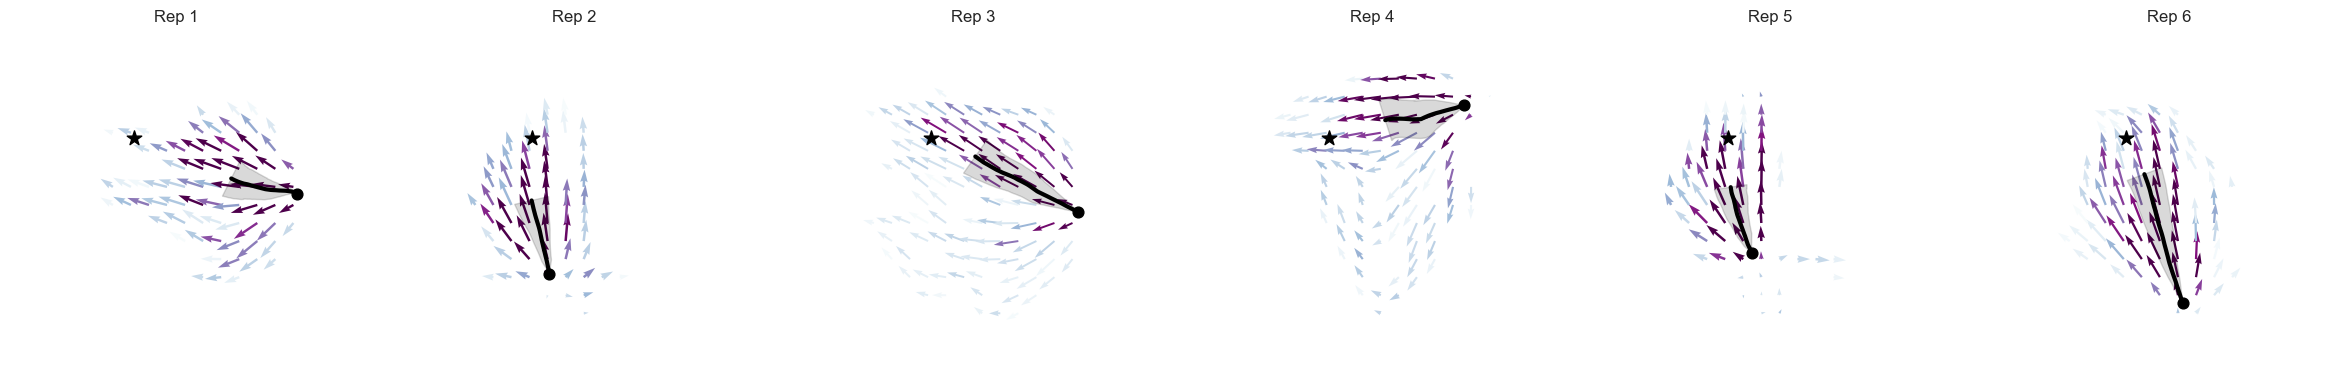

In [33]:

plot_navigation_object(
    trajectory_data,
    obj='vase',
    reps=[1,2,3,4,5,6]
)

